# 03 · Labeling — Quick Test & Validation
**Script chính:** `scripts/run_labeling.py`  
**Notebook này:** Load dataset_labeled → kiểm tra label distribution, barrier types, forward targets, coverage.

In [1]:
import sys, warnings
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

from src.config import load_config
from src.utils.io import load

cfg = load_config(ROOT / 'configs' / 'base.yaml')

## 1. Load & Validate Label Columns

In [2]:
df = load(cfg.dir_processed / 'dataset_labeled.parquet')

label_cols = ['tb_label', 'tb_barrier', 'tb_return', 'daily_vol', 't1', 'holding_td',
              'alpha_ret', 'alpha_label', 'alpha_ext_label']
present = [c for c in label_cols if c in df.columns]
missing = [c for c in label_cols if c not in df.columns]

print(f"Shape: {df.shape}")
print(f"Label columns present: {present}")
assert not missing, f"Missing label columns: {missing}"

# Check triple-barrier labels
tb = df['tb_label'].dropna()
assert set(tb.unique()).issubset({0, 1, 0.0, 1.0}), f"tb_label not binary: {tb.unique()}"
pos_rate = (tb == 1).mean()
print(f"\n--- Triple Barrier ---")
print(f"  Coverage: {len(tb):,} / {len(df):,} ({len(tb)/len(df):.1%})")
print(f"  Positive rate: {pos_rate:.1%}")
assert 0.3 < pos_rate < 0.7, f"tb_label pos_rate outside [30%,70%]: {pos_rate:.1%}"

# Check forward targets
alpha = df['alpha_ext_label'].dropna()
alpha_cov = len(alpha) / len(df)
alpha_pos = (alpha == 1).mean()
print(f"\n--- Forward Targets ---")
print(f"  alpha_ext_label coverage: {alpha_cov:.1%}")
print(f"  alpha_ext_label pos_rate: {alpha_pos:.1%}")
assert 0.2 < alpha_cov < 0.6, f"alpha_ext_label coverage unusual: {alpha_cov:.1%}"
assert 0.4 < alpha_pos < 0.6, f"alpha_ext_label pos_rate should be ~50%: {alpha_pos:.1%}"

print("\nOK: Label columns valid")

Shape: (173536, 89)
Label columns present: ['tb_label', 'tb_barrier', 'tb_return', 'daily_vol', 't1', 'holding_td', 'alpha_ret', 'alpha_label', 'alpha_ext_label']

--- Triple Barrier ---
  Coverage: 172,856 / 173,536 (99.6%)
  Positive rate: 54.0%

--- Forward Targets ---
  alpha_ext_label coverage: 38.1%
  alpha_ext_label pos_rate: 50.0%

OK: Label columns valid


## 1b. Data Inspection — nhìn thẳng vào labels

In `head/describe` của tất cả label columns + crosstab `tb_barrier × tb_label` + sample 1 ticker để xác nhận barrier touch + return + holding days hợp lý.

In [3]:
# LƯU Ý: head() trên dataset_labeled rơi vào 2016-01-04 (ngày đầu tiên = warmup),
# tb_label/barrier/return/daily_vol đều NaN vì cần 20 ngày quá khứ (vol_window) để tính daily_vol.
# Show 2 view: (a) head warmup để bạn thấy NaN pattern, (b) sample sau warmup — dữ liệu thực sự đi vào model.

print("--- (a) WARMUP rows: head(5) — phần lớn NaN, bình thường ---")
print(df[present].head(5).round(4).to_string())

print("\n--- (b) POST-WARMUP sample: 1 ngày ngẫu nhiên giữa dataset (2021-06-15) ---")
sample_date = pd.Timestamp('2021-06-15')
post_sample = df.loc[df.index.get_level_values('date') == sample_date, present]
if len(post_sample) == 0:
    # fallback: lấy ngày gần nhất sau warmup có labels populated
    populated_dates = df.dropna(subset=['tb_label']).index.get_level_values('date').unique()
    sample_date = populated_dates[len(populated_dates) // 2]
    post_sample = df.loc[df.index.get_level_values('date') == sample_date, present]
print(f"Date: {sample_date.date()} — {len(post_sample)} tickers")
print(post_sample.head(15).round(4).to_string())

print("\n--- (c) df[label_cols].describe() (chỉ tính trên non-NaN) ---")
print(df[present].describe().round(4).to_string())

print("\n--- (d) Crosstab: tb_barrier × tb_label (drop NaN) ---")
print(pd.crosstab(df['tb_barrier'], df['tb_label'], margins=True).to_string())

print("\n--- (e) Sample: AAPL labels — 10 ngày POST-warmup (từ 2017-01) ---")
aapl_lbl = df.xs('AAPL', level='ticker')[present]
aapl_post = aapl_lbl.loc[aapl_lbl.index >= '2017-01-01'].head(10)
print(aapl_post.round(4).to_string())

print("\n--- (f) Holding days breakdown ---")
print(df['holding_td'].describe().round(2).to_string())
print("\nValue counts (top 10 most common holding lengths):")
print(df['holding_td'].value_counts().head(10).to_string())

--- (a) WARMUP rows: head(5) — phần lớn NaN, bình thường ---
                   tb_label tb_barrier  tb_return  daily_vol  t1  holding_td  alpha_ret  alpha_label  alpha_ext_label
date       ticker                                                                                                    
2016-01-04 AAPL         NaN                   NaN        NaN NaT         NaN    -0.0899          0.0              NaN
           ADBE         NaN                   NaN        NaN NaT         NaN    -0.0312          0.0              1.0
           ADI          NaN                   NaN        NaN NaT         NaN    -0.1027          0.0              NaN
           ADP          NaN                   NaN        NaN NaT         NaN    -0.0439          0.0              NaN
           AMAT         NaN                   NaN        NaN NaT         NaN    -0.1158          0.0              NaN

--- (b) POST-WARMUP sample: 1 ngày ngẫu nhiên giữa dataset (2021-06-15) ---
Date: 2021-06-15 — 68 tickers
      

## 2. Barrier Type Distribution & Label Over Time

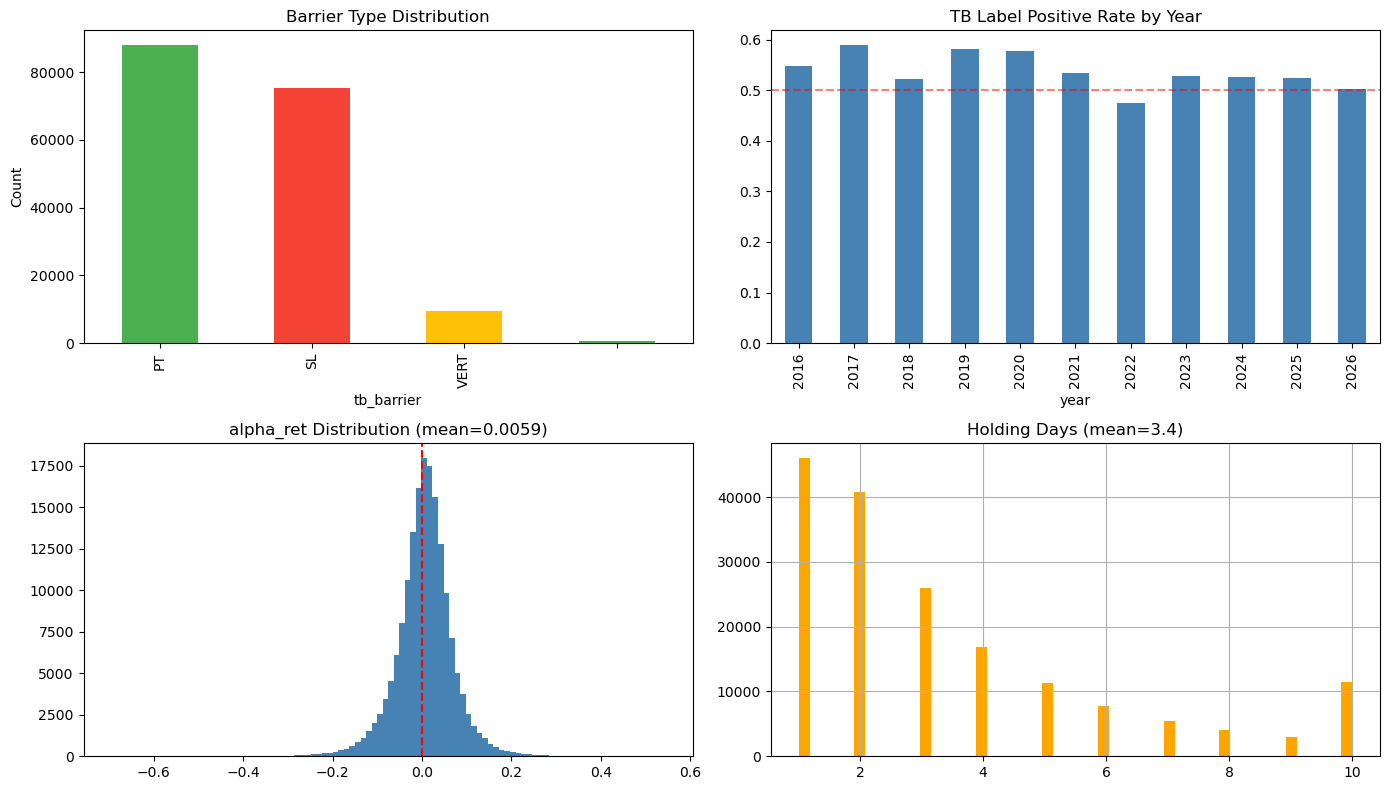

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# (a) Barrier type distribution
if 'tb_barrier' in df.columns:
    barrier_counts = df['tb_barrier'].value_counts()
    barrier_counts.plot(kind='bar', ax=axes[0, 0], color=['#4CAF50', '#F44336', '#FFC107'])
    axes[0, 0].set_title('Barrier Type Distribution')
    axes[0, 0].set_ylabel('Count')

# (b) Positive rate over time (yearly)
flat = df.reset_index()
flat['year'] = flat['date'].dt.year
yearly_pos = flat.groupby('year')['tb_label'].mean()
yearly_pos.plot(kind='bar', ax=axes[0, 1], color='steelblue')
axes[0, 1].set_title('TB Label Positive Rate by Year')
axes[0, 1].axhline(0.5, ls='--', color='red', alpha=0.5)

# (c) alpha_ret distribution
if 'alpha_ret' in df.columns:
    alpha_ret = df['alpha_ret'].dropna()
    axes[1, 0].hist(alpha_ret, bins=100, color='steelblue', edgecolor='none')
    axes[1, 0].axvline(0, color='red', ls='--')
    axes[1, 0].set_title(f'alpha_ret Distribution (mean={alpha_ret.mean():.4f})')

# (d) Holding days distribution
if 'holding_td' in df.columns:
    df['holding_td'].dropna().hist(bins=50, ax=axes[1, 1], color='orange', edgecolor='none')
    axes[1, 1].set_title(f'Holding Days (mean={df["holding_td"].mean():.1f})')

plt.tight_layout()
plt.show()

## 3. Cross-check vs Script Label Summary

## 4. Forward-target return distributions

Forward returns at multiple horizons drive `alpha_label` / `alpha_ext_label`. Their spread tells us how much actionable signal exists at each horizon.

In [5]:
fwd_cols = [c for c in df.columns if c.startswith('fwd_ret_')]
if fwd_cols:
    fig, axes = plt.subplots(1, len(fwd_cols), figsize=(4 * len(fwd_cols), 3.5), sharey=True)
    if len(fwd_cols) == 1: axes = [axes]
    for ax, col in zip(axes, fwd_cols):
        s = df[col].dropna()
        ax.hist(s, bins=80, color='steelblue', edgecolor='none')
        ax.axvline(0, color='red', ls='--', alpha=0.5)
        ax.set_title(f'{col}\nmean={s.mean():.4f} std={s.std():.4f}')
        ax.set_xlim(s.quantile(0.005), s.quantile(0.995))
    plt.tight_layout(); plt.show()
    print({c: float(df[c].std()) for c in fwd_cols})
else:
    print('No fwd_ret_* columns; forward targets not generated.')

No fwd_ret_* columns; forward targets not generated.


## 5. Barrier outcome × year heatmap

Does barrier composition (TP / SL / TIME) drift across the regime cycle?

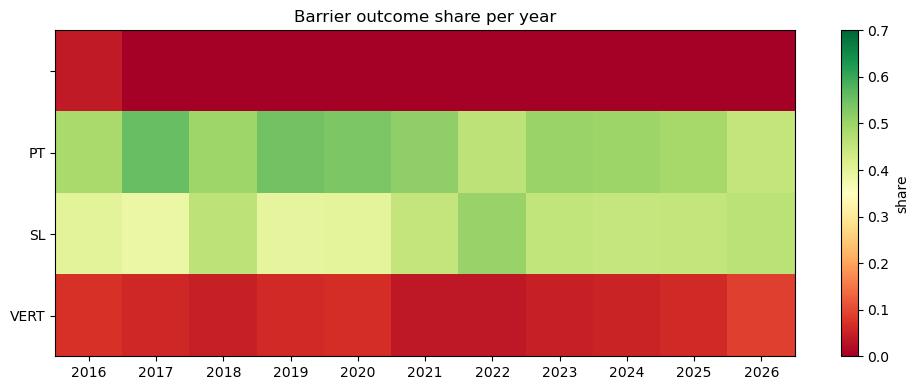

In [6]:
if 'tb_barrier' in df.columns:
    flat2 = df.reset_index()
    flat2['year'] = flat2['date'].dt.year
    heat = flat2.groupby(['year', 'tb_barrier']).size().unstack(fill_value=0)
    heat_pct = heat.div(heat.sum(axis=1), axis=0)
    fig, ax = plt.subplots(figsize=(10, 4))
    im = ax.imshow(heat_pct.T.values, aspect='auto', cmap='RdYlGn', vmin=0, vmax=0.7)
    ax.set_xticks(range(len(heat_pct.index)))
    ax.set_xticklabels(heat_pct.index, rotation=0)
    ax.set_yticks(range(len(heat_pct.columns)))
    ax.set_yticklabels(heat_pct.columns)
    ax.set_title('Barrier outcome share per year')
    plt.colorbar(im, ax=ax, label='share'); plt.tight_layout(); plt.show()

In [7]:
label_csv = cfg.dir_outputs / 'metrics' / 'label_summary.csv'
if label_csv.exists():
    summary = pd.read_csv(label_csv)
    print("Script label_summary.csv:")
    print(summary.to_string(index=False))
    
    # Cross-check key stats
    script_nrows = int(summary[summary['metric'] == 'n_rows']['value'].iloc[0])
    assert script_nrows == len(df), f"Row count mismatch: script={script_nrows} vs nb={len(df)}"
    print(f"\nOK: Row count matches ({script_nrows:,})")
else:
    print("SKIP: label_summary.csv not found — run scripts/run_labeling.py first")

print("\n" + "=" * 50)
print("03_labeling: ALL CHECKS PASSED")
print(f"  Rows: {len(df):,}")
print(f"  TB pos_rate: {pos_rate:.1%}")
print(f"  alpha_ext coverage: {alpha_cov:.1%}, pos_rate: {alpha_pos:.1%}")
print("=" * 50)

Script label_summary.csv:
                  metric         value
                  n_rows 173536.000000
               n_tickers     68.000000
               label_pos  93389.000000
               label_neg  79467.000000
                pos_rate      0.538153
          avg_holding_td      3.410064
    alpha_label_pos_rate      0.146540
alpha_ext_label_pos_rate      0.190502
alpha_ext_label_coverage      0.381005
          alpha_ret_mean      0.005938

OK: Row count matches (173,536)

03_labeling: ALL CHECKS PASSED
  Rows: 173,536
  TB pos_rate: 54.0%
  alpha_ext coverage: 38.1%, pos_rate: 50.0%
